In [1]:
import warnings
warnings.filterwarnings("ignore")
import tensorflow as tf
import matplotlib.pyplot as plt
tf.compat.v1.set_random_seed(0)
from tensorflow import keras
import numpy as np
np.random.seed(0)
import itertools
from keras.preprocessing.image import image_dataset_from_directory
from tensorflow.keras.layers.experimental.preprocessing import Rescaling
from sklearn.metrics import precision_score, accuracy_score, recall_score, confusion_matrix, ConfusionMatrixDisplay

In [2]:
# Print all disease (class) names from the dataset
train_gen = image_dataset_from_directory(directory="../input/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train",
                                         image_size=(256, 256))
test_gen = image_dataset_from_directory(directory="../input/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/valid",
                                        image_size=(256, 256))
print("Disease Classes in the Dataset:")
for idx, class_name in enumerate(train_gen.class_names):
    print(f"{idx}: {class_name}")


Found 70295 files belonging to 38 classes.
Found 17572 files belonging to 38 classes.
Disease Classes in the Dataset:
0: Apple___Apple_scab
1: Apple___Black_rot
2: Apple___Cedar_apple_rust
3: Apple___healthy
4: Blueberry___healthy
5: Cherry_(including_sour)___Powdery_mildew
6: Cherry_(including_sour)___healthy
7: Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
8: Corn_(maize)___Common_rust_
9: Corn_(maize)___Northern_Leaf_Blight
10: Corn_(maize)___healthy
11: Grape___Black_rot
12: Grape___Esca_(Black_Measles)
13: Grape___Leaf_blight_(Isariopsis_Leaf_Spot)
14: Grape___healthy
15: Orange___Haunglongbing_(Citrus_greening)
16: Peach___Bacterial_spot
17: Peach___healthy
18: Pepper,_bell___Bacterial_spot
19: Pepper,_bell___healthy
20: Potato___Early_blight
21: Potato___Late_blight
22: Potato___healthy
23: Raspberry___healthy
24: Soybean___healthy
25: Squash___Powdery_mildew
26: Strawberry___Leaf_scorch
27: Strawberry___healthy
28: Tomato___Bacterial_spot
29: Tomato___Early_blight
30: Toma

In [ ]:
#train_gen = image_dataset_from_directory(directory="../input/new-plant-diseases-dataset/train",image_size=(256, 256))
#test_gen = image_dataset_from_directory(directory="../input/new-plant-diseases-dataset/valid",image_size=(256, 256))

train_gen = image_dataset_from_directory(directory="../input/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train",
                                         image_size=(256, 256))
test_gen = image_dataset_from_directory(directory="../input/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/valid",
                                        image_size=(256, 256))

rescale = Rescaling(scale=1.0/255)
train_gen = train_gen.map(lambda image,label:(rescale(image),label))
test_gen  = test_gen.map(lambda image,label:(rescale(image),label))
# Print all disease (class) names from the dataset


Found 70295 files belonging to 38 classes.
Found 17572 files belonging to 38 classes.


<h1>Modelling</h1>

In [4]:
model = keras.Sequential()

model.add(keras.layers.Conv2D(32,(3,3),activation="relu",padding="same",input_shape=(256,256,3)))
model.add(keras.layers.Conv2D(32,(3,3),activation="relu",padding="same"))
model.add(keras.layers.MaxPooling2D(3,3))

model.add(keras.layers.Conv2D(64,(3,3),activation="relu",padding="same"))
model.add(keras.layers.Conv2D(64,(3,3),activation="relu",padding="same"))
model.add(keras.layers.MaxPooling2D(3,3))

model.add(keras.layers.Conv2D(128,(3,3),activation="relu",padding="same"))
model.add(keras.layers.Conv2D(128,(3,3),activation="relu",padding="same"))
model.add(keras.layers.MaxPooling2D(3,3))

model.add(keras.layers.Conv2D(256,(3,3),activation="relu",padding="same"))
model.add(keras.layers.Conv2D(256,(3,3),activation="relu",padding="same"))

model.add(keras.layers.Conv2D(512,(5,5),activation="relu",padding="same"))
model.add(keras.layers.Conv2D(512,(5,5),activation="relu",padding="same"))

model.add(keras.layers.Flatten())

model.add(keras.layers.Dense(1568,activation="relu"))
model.add(keras.layers.Dropout(0.5))

model.add(keras.layers.Dense(38,activation="softmax"))

opt = keras.optimizers.Adam(learning_rate=0.0001)
model.compile(optimizer=opt,loss="sparse_categorical_crossentropy",metrics=['accuracy'])
model.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d (Conv2D)              (None, 256, 256, 32)      896       
_________________________________________________________________
conv2d_1 (Conv2D)            (None, 256, 256, 32)      9248      
_________________________________________________________________
max_pooling2d (MaxPooling2D) (None, 85, 85, 32)        0         
_________________________________________________________________
conv2d_2 (Conv2D)            (None, 85, 85, 64)        18496     
_________________________________________________________________
conv2d_3 (Conv2D)            (None, 85, 85, 64)        36928     
_________________________________________________________________
max_pooling2d_1 (MaxPooling2 (None, 28, 28, 64)        0         
_________________________________________________________________
conv2d_4 (Conv2D)            (None, 28, 28, 128)       7

In [5]:
ep = 10
history = model.fit_generator(train_gen,
          validation_data=test_gen,
          epochs = ep)

Epoch 1/10
2197/2197 [==============================] - 205s 89ms/step - loss: 1.5375 - accuracy: 0.5511 - val_loss: 0.5845 - val_accuracy: 0.8156
Epoch 2/10
2197/2197 [==============================] - 174s 79ms/step - loss: 0.4398 - accuracy: 0.8601 - val_loss: 0.3434 - val_accuracy: 0.8863
Epoch 3/10
2197/2197 [==============================] - 174s 79ms/step - loss: 0.2603 - accuracy: 0.9152 - val_loss: 0.2623 - val_accuracy: 0.9096
Epoch 4/10
2197/2197 [==============================] - 173s 79ms/step - loss: 0.1752 - accuracy: 0.9405 - val_loss: 0.1866 - val_accuracy: 0.9363
Epoch 5/10
2197/2197 [==============================] - 174s 79ms/step - loss: 0.1310 - accuracy: 0.9567 - val_loss: 0.1836 - val_accuracy: 0.9388
Epoch 6/10
2197/2197 [==============================] - 174s 79ms/step - loss: 0.1016 - accuracy: 0.9661 - val_loss: 0.1264 - val_accuracy: 0.9579
Epoch 7/10
2197/2197 [==============================] - 173s 79ms/step - loss: 0.0783 - accuracy: 0.9741 - val_loss: 0

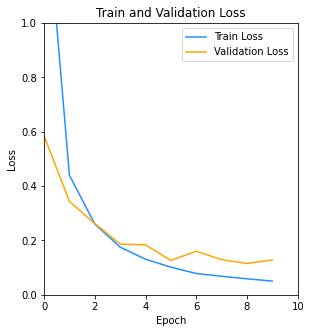

In [6]:
plt.figure(figsize=(10, 5))

# Plot for Loss
plt.subplot(1, 2, 1)
plt.title("Train and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.plot(history.history['loss'], label="Train Loss", color='dodgerblue')         # blue
plt.plot(history.history['val_loss'], label="Validation Loss", color='orange')    # orange
plt.xlim(0, 10)
plt.ylim(0.0, 1.0)
plt.legend()

<h1>Metrics</h1>

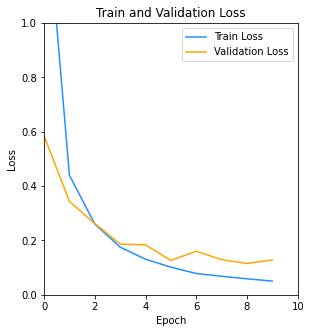

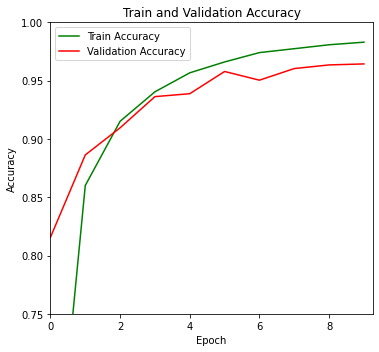

In [7]:
# plt.figure(figsize = (20,5))
# plt.subplot(1,2,1)
# plt.title("Train and Validation Loss")
# plt.xlabel("Epoch")
# plt.ylabel("Loss")
# plt.plot(history.history['loss'],label="Train Loss")
# plt.plot(history.history['val_loss'], label="Validation Loss")
# plt.xlim(0, 10)
# plt.ylim(0.0,1.0)
# plt.legend()

# plt.subplot(1,2,2)
# plt.title("Train and Validation Accuracy")
# plt.xlabel("Epoch")
# plt.ylabel("Accuracy")
# plt.plot(history.history['accuracy'], label="Train Accuracy")
# plt.plot(history.history['val_accuracy'], label="Validation Accuracy")
# plt.xlim(0, 9.25)
# plt.ylim(0.75,1.0)
# plt.legend()
# plt.tight_layout()
plt.figure(figsize=(10, 5))

# Plot for Loss
plt.subplot(1, 2, 1)
plt.title("Train and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.plot(history.history['loss'], label="Train Loss", color='dodgerblue')         # blue
plt.plot(history.history['val_loss'], label="Validation Loss", color='orange')    # orange
plt.xlim(0, 10)
plt.ylim(0.0, 1.0)
plt.legend()
plt.figure(figsize=(10, 5))
# Plot for Accuracy
plt.subplot(1, 2, 2)
plt.title("Train and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.plot(history.history['accuracy'], label="Train Accuracy", color='green')            # green
plt.plot(history.history['val_accuracy'], label="Validation Accuracy", color='red')     # red
plt.xlim(0, 9.25)
plt.ylim(0.75, 1.0)
plt.legend()

plt.tight_layout()
plt.show()

In [8]:
labels = []
predictions = []
for x,y in test_gen:
    labels.append(list(y.numpy()))
    predictions.append(tf.argmax(model.predict(x),1).numpy())

In [9]:
predictions = list(itertools.chain.from_iterable(predictions))
labels = list(itertools.chain.from_iterable(labels))

In [10]:
print("Train Accuracy  : {:.2f} %".format(history.history['accuracy'][-1]*100))
print("Test Accuracy   : {:.2f} %".format(accuracy_score(labels, predictions) * 100))
print("Precision Score : {:.2f} %".format(precision_score(labels, predictions, average='micro') * 100))
print("Recall Score    : {:.2f} %".format(recall_score(labels, predictions, average='micro') * 100))

Train Accuracy  : 98.30 %
Test Accuracy   : 96.44 %
Precision Score : 96.44 %
Recall Score    : 96.44 %


<Figure size 1440x360 with 0 Axes>

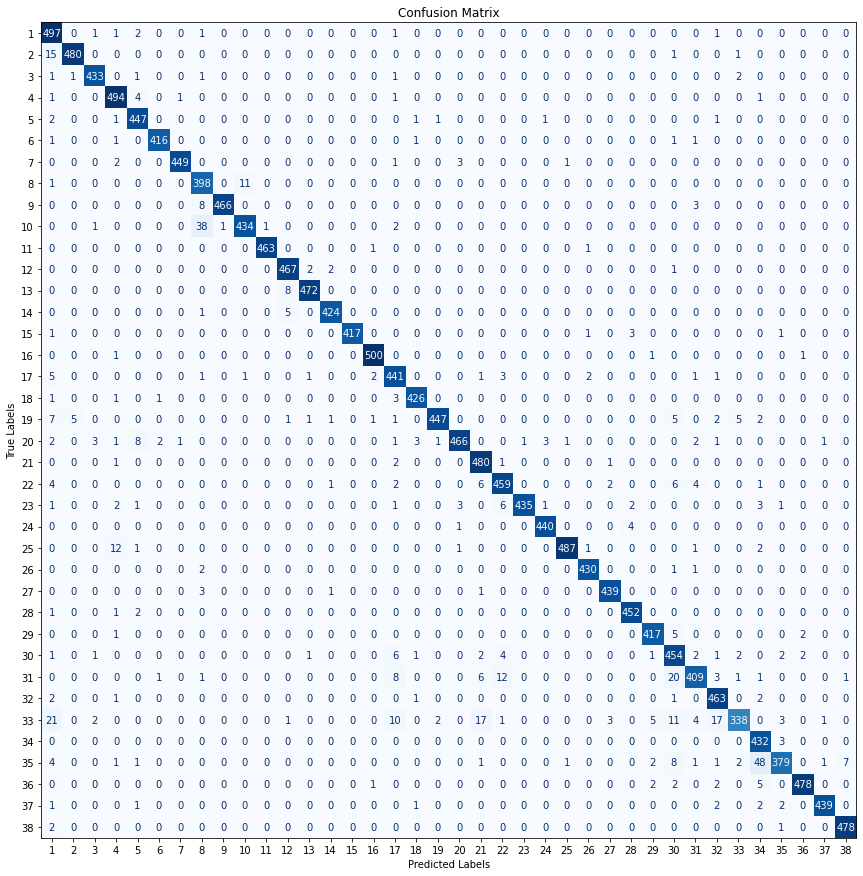

In [11]:
# plt.figure(figsize= (20,5))
# cm = confusion_matrix(labels, predictions)
# disp = ConfusionMatrixDisplay(confusion_matrix=cm,
#                               display_labels=list(range(1,39)))
# fig, ax = plt.subplots(figsize=(15,15))
# disp.plot(ax=ax,colorbar= False,cmap = 'YlGnBu')
# plt.title("Confusion Matrix")
# plt.xlabel('Predicted Labels')
# plt.ylabel('True Labels')
# plt.show()
plt.figure(figsize=(20, 5))
cm = confusion_matrix(labels, predictions)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list(range(1, 39)))
fig, ax = plt.subplots(figsize=(15, 15))
disp.plot(ax=ax, colorbar=False, cmap='Blues')  # changed colormap here
plt.title("Confusion Matrix")
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

In [12]:
# Disease-to-Pesticide mapping (simplified example, can be expanded or customized)
disease_to_pesticide = {
    "Apple___Apple_scab": "Captan, Mancozeb",
    "Apple___Black_rot": "Ziram, Captan",
    "Apple___Cedar_apple_rust": "Myclobutanil",
    "Apple___healthy": "No pesticide needed",
    "Blueberry___healthy": "No pesticide needed",
    "Cherry_(including_sour)___Powdery_mildew": "Sulfur, Myclobutanil",
    "Cherry_(including_sour)___healthy": "No pesticide needed",
    "Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot": "Strobilurins",
    "Corn_(maize)___Common_rust_": "Propiconazole",
    "Corn_(maize)___Northern_Leaf_Blight": "Azoxystrobin",
    "Corn_(maize)___healthy": "No pesticide needed",
    "Grape___Black_rot": "Mancozeb, Captan",
    "Grape___Esca_(Black_Measles)": "No effective chemical control",
    "Grape___Leaf_blight_(Isariopsis_Leaf_Spot)": "Mancozeb",
    "Grape___healthy": "No pesticide needed",
    "Orange___Haunglongbing_(Citrus_greening)": "Vector control: Imidacloprid",
    "Peach___Bacterial_spot": "Copper-based sprays",
    "Peach___healthy": "No pesticide needed",
    "Pepper,_bell___Bacterial_spot": "Copper-based sprays",
    "Pepper,_bell___healthy": "No pesticide needed",
    "Potato___Early_blight": "Chlorothalonil, Mancozeb",
    "Potato___Late_blight": "Metalaxyl, Mancozeb",
    "Potato___healthy": "No pesticide needed",
    "Raspberry___healthy": "No pesticide needed",
    "Soybean___healthy": "No pesticide needed",
    "Squash___Powdery_mildew": "Sulfur, Neem oil",
    "Strawberry___Leaf_scorch": "Captan",
    "Strawberry___healthy": "No pesticide needed",
    "Tomato___Bacterial_spot": "Copper sprays",
    "Tomato___Early_blight": "Chlorothalonil, Mancozeb",
    "Tomato___Late_blight": "Metalaxyl",
    "Tomato___Leaf_Mold": "Copper-based fungicides",
    "Tomato___Septoria_leaf_spot": "Chlorothalonil",
    "Tomato___Spider_mites Two-spotted_spider_mite": "Insecticidal soap, Neem oil",
    "Tomato___Target_Spot": "Chlorothalonil",
    "Tomato___Tomato_Yellow_Leaf_Curl_Virus": "Vector control: Imidacloprid",
    "Tomato___Tomato_mosaic_virus": "Sanitation, resistant varieties",
    "Tomato___healthy": "No pesticide needed"
}


In [13]:
train_gen = image_dataset_from_directory(
    directory="../input/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train",
    image_size=(256, 256),
    shuffle=True
)
class_names = train_gen.class_names  # ✅ Save class names in a separate variable


Found 70295 files belonging to 38 classes.


In [14]:
# from PIL import Image

# def predict_disease_and_recommend(image_path):
#     # Load and preprocess image
#     img = tf.keras.preprocessing.image.load_img(image_path, target_size=(256, 256))
#     img_array = tf.keras.preprocessing.image.img_to_array(img) / 255.0
#     img_array = tf.expand_dims(img_array, 0)  # Add batch dimension

#     # Predict
#     predictions = model.predict(img_array)
#     predicted_class = train_gen.class_names[np.argmax(predictions)]
#     pesticide = disease_to_pesticide.get(predicted_class, "No data available")
#     plt.figure(figsize=(6, 6))
#     plt.imshow(img)
#     plt.axis('off')
#     plt.title(f"Disease: {predicted_class}\nPesticide: {pesticide}",
#               fontsize=12, color='darkgreen', loc='center')
#     plt.tight_layout()
#     plt.show()

#     print(f"\n📷 Predicted Disease: {predicted_class}")
#     print(f"🧪 Recommended Pesticide: {pesticide}")
import matplotlib.pyplot as plt
from PIL import Image
import os

def predict_disease_and_recommend(image_path, save_output=True):
    # Load and preprocess image
    img = tf.keras.preprocessing.image.load_img(image_path, target_size=(256, 256))
    img_array = tf.keras.preprocessing.image.img_to_array(img) / 255.0
    img_array = tf.expand_dims(img_array, 0)  # Add batch dimension

    # Predict
    predictions = model.predict(img_array)
    predicted_class = class_names[np.argmax(predictions)]
    pesticide = disease_to_pesticide.get(predicted_class, "No data available")

    # Display and save image with overlayed text
    plt.figure(figsize=(6, 6))
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"Disease: {predicted_class}\nPesticide: {pesticide}",
              fontsize=12, color='darkgreen', loc='center')
    plt.tight_layout()

    if save_output:
        output_path = "prediction_output.png"
        plt.savefig(output_path)
        print(f"\n🖼️ Image saved to: {os.path.abspath(output_path)}")

    plt.show()



🖼️ Image saved to: /kaggle/working/prediction_output.png


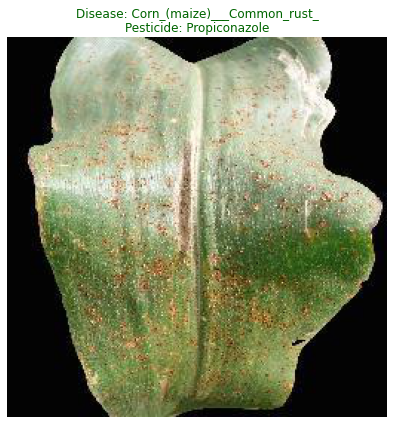

In [15]:
# Just call this function with the path to your image
predict_disease_and_recommend("/kaggle/input/new-plant-diseases-dataset/test/test/CornCommonRust2.JPG")



🖼️ Image saved to: /kaggle/working/prediction_output.png


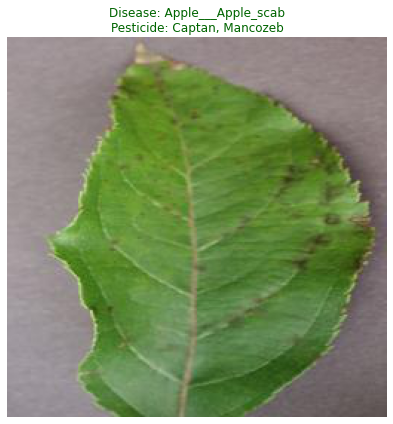

In [16]:
predict_disease_and_recommend("/kaggle/input/new-plant-diseases-dataset/test/test/AppleScab1.JPG")


🖼️ Image saved to: /kaggle/working/prediction_output.png


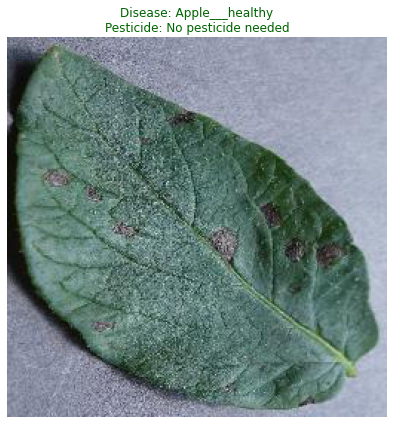

In [17]:
predict_disease_and_recommend("/kaggle/input/new-plant-diseases-dataset/test/test/PotatoEarlyBlight3.JPG")


🖼️ Image saved to: /kaggle/working/prediction_output.png


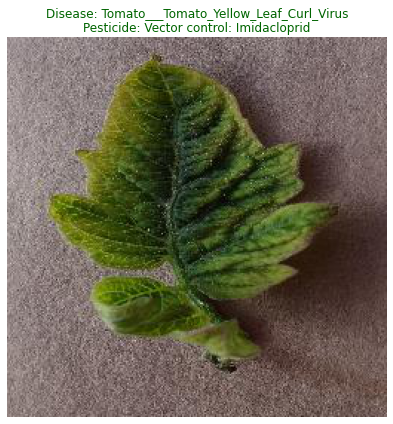

In [18]:
predict_disease_and_recommend("/kaggle/input/new-plant-diseases-dataset/test/test/TomatoYellowCurlVirus1.JPG")


🖼️ Image saved to: /kaggle/working/prediction_output.png


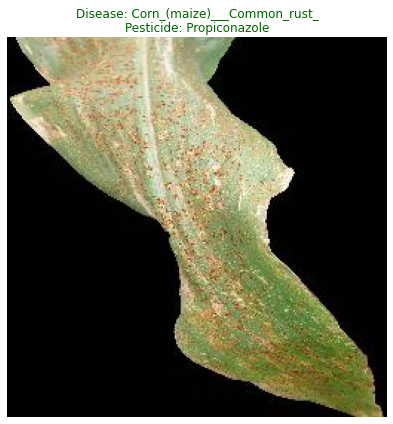

In [19]:
predict_disease_and_recommend("/kaggle/input/new-plant-diseases-dataset/test/test/CornCommonRust3.JPG")